In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
init_run = 35
end_run = 36

## Curvas SET

In [3]:
root_data_path = Path.cwd() / "Datos_Experimentales" / "Medidas_Arturo"
data_path = root_data_path / "DC_Set#1_1000nm-D.xlsx"

nombre_txt = "D_Set_1_Run"
voltage_column_name = "DrainV" 
current_column_name = "DrainI"

In [4]:
# Lee todas las hojas
sheets = pd.read_excel(data_path, sheet_name=None)  # dict: nombre_hoja -> DataFrame

df_dict_set = {}
    
for run in range(init_run, end_run):  # de 4 a 64 inclusive
    sheet_name = f"Run{run}"
    if sheet_name not in sheets:
        continue  # por si falta alguna hoja

    df = sheets[sheet_name]

    # Eliminar columna GateV si existe
    if "GateV" in df.columns:
        df = df.drop(columns=["GateV"])

    # Renombrar columnas
    df = df.rename(
        columns={
            "Time": "Time (s)",
            current_column_name: "Current (A)",
            voltage_column_name: "Voltage (V)",
        }
    )
    
    # Almaceno el dataframe en un diccionario con la clave del número de run
    df_dict_set[run] = df
    
    # ESto es para escribir el fichero, lo dejo para solo sacar el me interesa
    txt_path = root_data_path / f"{nombre_txt}{run}.txt"

    df.to_csv(txt_path, sep="\t", index=False)


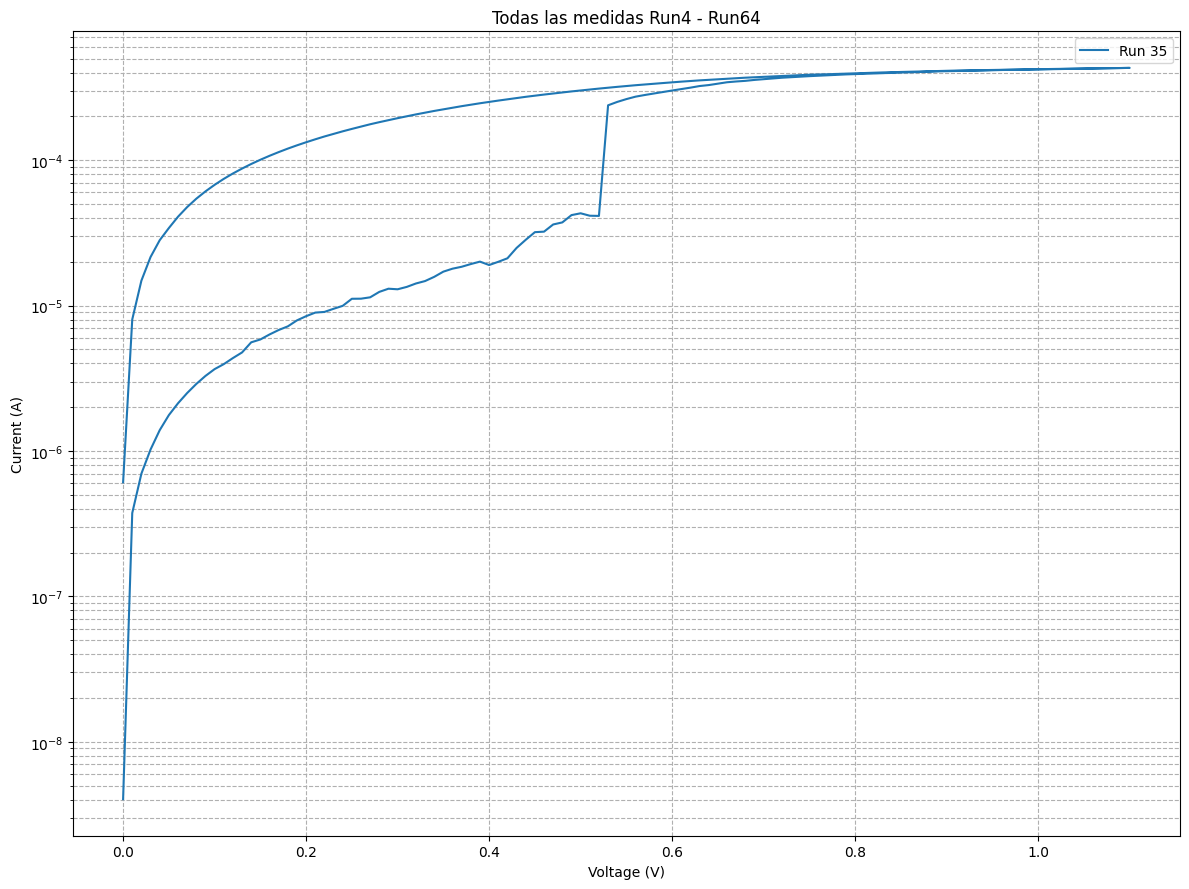

In [5]:
runs = range(init_run, end_run)  # Run4 ... Run64

# Quito el run 21 y el 17 (que está mal)
runs = [run for run in runs if run not in (5, 17, 21,27)] # Para el set 1 D


data_frames_set = {}
for run in runs:
    df = df_dict_set[run]  # lee tabulado
    df = df.rename(
        columns={
            "Time": "Time (s)",
            current_column_name: "Current (A)",
            voltage_column_name: "Voltage (V)",
        }
    )
    # print(f"Run {run}: ", df.columns.tolist())
    data_frames_set[run] = df

plt.figure(figsize=(12, 9))
i = 0
for run, df in data_frames_set.items():
    x = df["Voltage (V)"]
    y = df["Current (A)"]
    plt.semilogy(x, y, label=f"Run {run}")

    # Coordenadas del último punto
    x_last = x.iloc[-1]
    y_last = y.iloc[-1]

    # # Texto ligeramente desplazado para que no se superponga con la curva
    # plt.text(x_last+i, y_last, f"{run}", fontsize=18, ha="left", va="bottom")
    # i = i + 0.1
plt.xlabel("Voltage (V)")
plt.ylabel("Current (A)")
plt.title("Todas las medidas Run4 - Run64")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()


## Curvas RESET

In [6]:
root_data_path = Path.cwd() / "Datos_Experimentales" / "Medidas_Arturo"
data_path = root_data_path / "DC_Reset#1_1000nm-D.xlsx"

nombre_txt = "D_Reset_1_Run"
voltage_column_name = "SourceV"
current_column_name = "SourceI"


In [7]:
# Lee todas las hojas
sheets = pd.read_excel(data_path, sheet_name=None)  # dict: nombre_hoja -> DataFrame

df_dict_reset = {}
for run in range(init_run, end_run):  # de 4 a 64 inclusive
    sheet_name = f"Run{run}"
    if sheet_name not in sheets:
        continue  # por si falta alguna hoja

    df = sheets[sheet_name]

    # Eliminar columna GateV si existe
    if "GateV" in df.columns:
        df = df.drop(columns=["GateV"])

    # Renombrar columnas
    df = df.rename(
        columns={
            "Time": "Time (s)",
            current_column_name: "Current (A)",
            voltage_column_name: "Voltage (V)",
        }
    )

    # Almaceno el dataframe en un diccionario con la clave del número de run
    df_dict_reset[run] = df

    txt_path = root_data_path / f"{nombre_txt}{run}.txt"
    df.to_csv(txt_path, sep="\t", index=False)


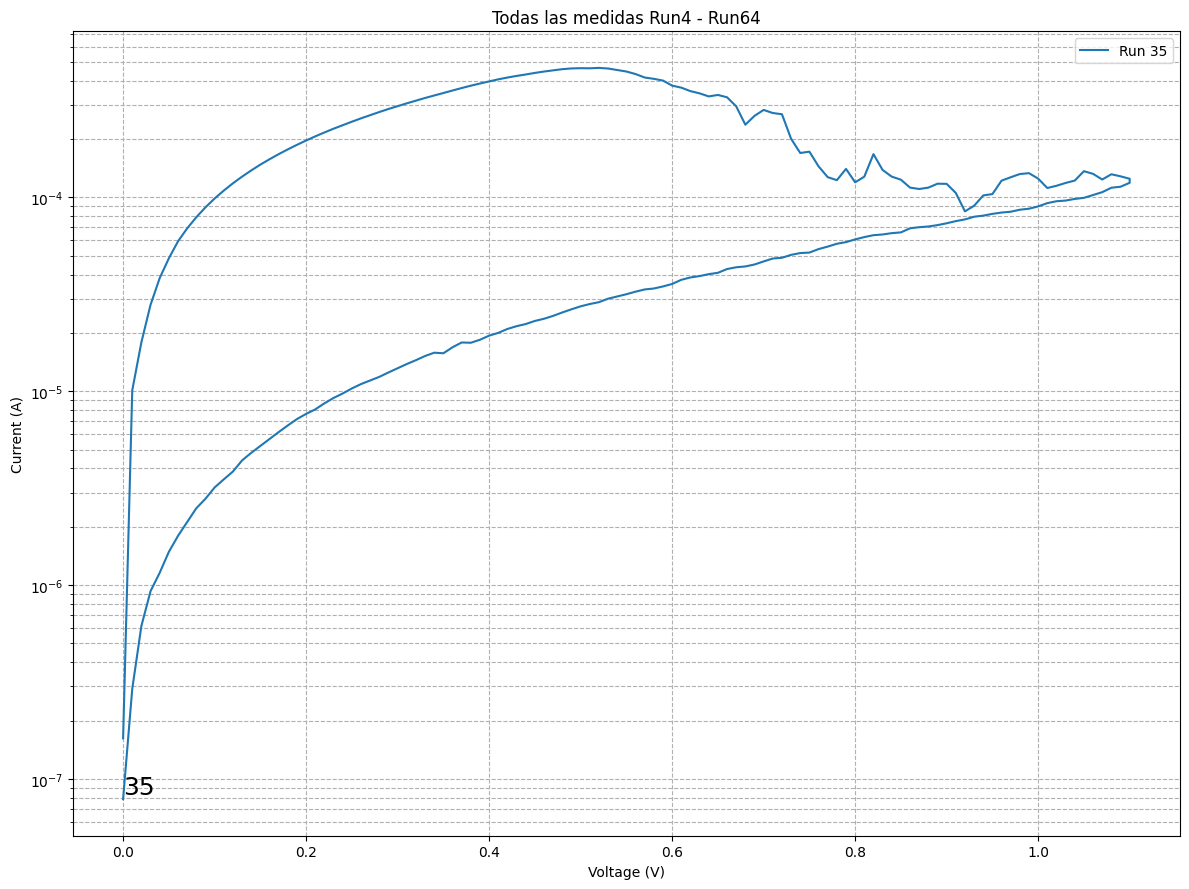

In [8]:
runs = range(init_run, end_run)  # Run4 ... Run64

# runs = [run for run in runs if run not in (17,4,27, 21, 64,5)] # Para el set 2 D
runs = [run for run in runs if run not in (23, 11, 19, 29, 16)]  # Para el reset 1 D
# runs = [run for run in runs if run not in (23,11,19,29,16)] # Para el set 1 MIM

data_frames_reset = {}
for run in runs:
    txt_name = f"{nombre_txt}{run}.txt"
    txt_path = root_data_path / txt_name
    df = df_dict_reset[run]  # lee tabulado
    df = df.rename(
        columns={
            "Time": "Time (s)",
            current_column_name: "Current (A)",
            voltage_column_name: "Voltage (V)",
        }
    )
    # print(f"Run {run}: ", df.columns.tolist())
    data_frames_reset[run] = df

plt.figure(figsize=(12, 9))
i = 0
for run, df in data_frames_reset.items():
    x = df["Voltage (V)"]
    y = df["Current (A)"]
    plt.semilogy(x, y, label=f"Run {run}")

    # Coordenadas del último punto
    x_last = x.iloc[-1]
    y_last = y.iloc[-1]

    # Texto ligeramente desplazado para que no se superponga con la curva
    plt.text(x_last + i, y_last, f"{run}", fontsize=18, ha="left", va="bottom")
    i = i + 0.1
plt.xlabel("Voltage (V)")
plt.ylabel("Current (A)")
plt.title("Todas las medidas Run4 - Run64")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()


## Curva I-V

C:\Users\Usuario\AppData\Local\Temp\ipykernel_147060\2687094739.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(runs) + 1)  # Usa un colormap con suficientes colores


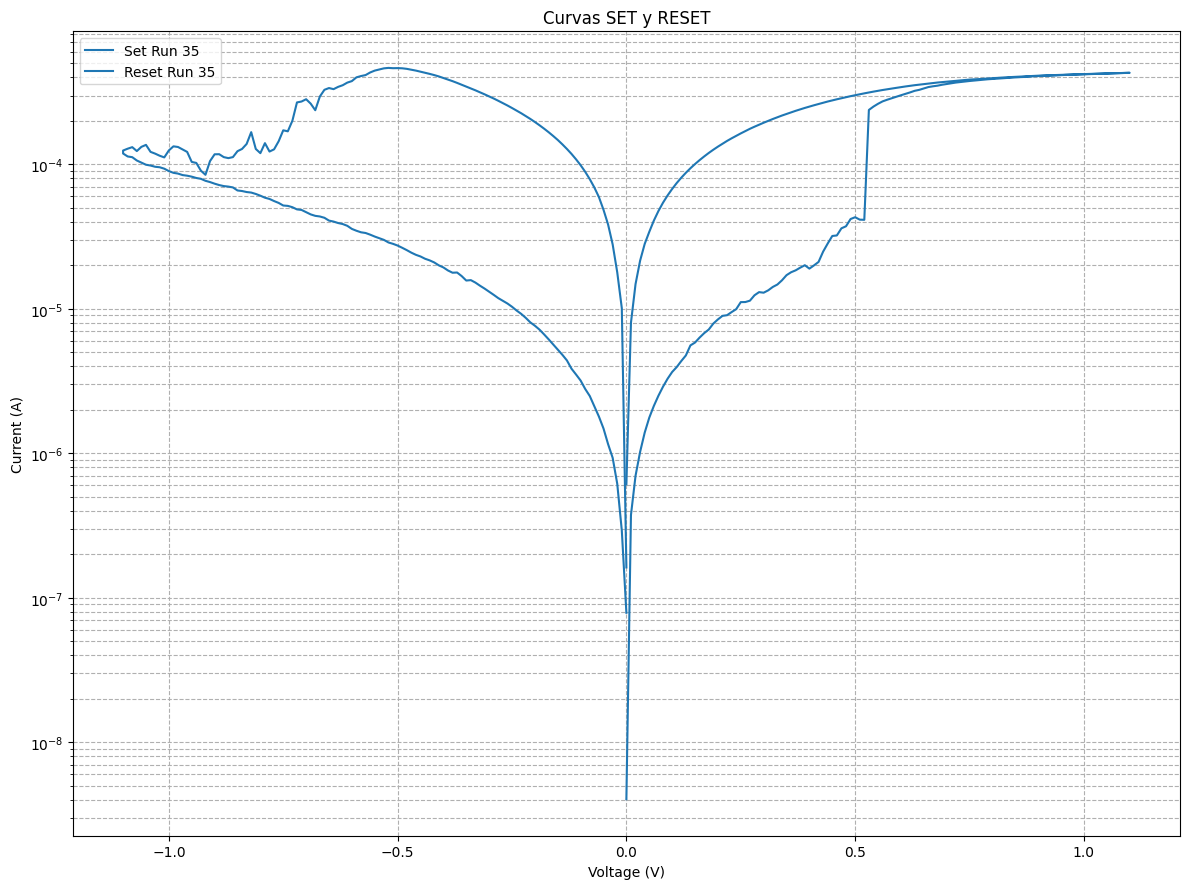

In [9]:
import numpy as np

import matplotlib.cm as cm

plt.figure(figsize=(12, 9))

# Generar una lista de colores única para cada run
colors = cm.get_cmap('tab10', len(runs) + 1)  # Usa un colormap con suficientes colores

for idx, run in enumerate(runs):  # Usa el índice para asignar colores
    if run not in data_frames_set or run not in data_frames_reset:
        print(f"Run {run} no se encuentra en los diccionarios de datos.")
        continue  # Si no se encuentra, pasa al siguiente run
    
    df_set = data_frames_set[run]  # Accede a los datos de set
    df_reset = data_frames_reset[run]  # Accede a los datos de reset
    
    V_set = df_set["Voltage (V)"]
    I_set = df_set["Current (A)"]
    V_reset = -df_reset["Voltage (V)"]  # Invierte el voltaje de reset
    I_reset = abs(df_reset["Current (A)"])  # Toma el valor absoluto de la corriente de reset
    
    color = colors(idx)  # Asigna un color único basado en el índice
    plt.semilogy(V_set, I_set, label=f"Set Run {run}", color=color)
    plt.semilogy(V_reset, I_reset, label=f"Reset Run {run}", color=color)

plt.xlabel("Voltage (V)")
plt.ylabel("Current (A)")
plt.title("Curvas SET y RESET")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()
